Question1:

part1:

In [2]:
Bin_pmf <-function(n,p,x){
    q <- (1-p)^(n-x)
    choose_from <- choose(n,x)
    PMF <- choose_from*(p^x)*q
  return(PMF)
}

Bin_cdf <- function(n,p,random_vars){
    cdf <- c()
    for (x in random_vars){
        cdf <- c(cdf,Bin_pmf(n,p,x))
    }
    return (sum(cdf))
}

In [3]:
x <- 0:430
n <- 1000
p <- 0.45

cdf <- Bin_cdf(n,p,x)
cdf

[1] 0.1074638

part2: bedoon khatay peyvastegi

In [4]:
x <- 430
mean <- n*p
std <- sqrt(n*p*(1-p))
normal_distribution <- pnorm(x,m=mean,s=std)
print(normal_distribution)
error <- abs(normal_distribution-cdf)
print(error)

[1] 0.1018139
[1] 0.005649884


part3:

In [5]:
normal_distribution_with_correction <- pnorm(x+0.5,m=mean,s=std)
print(normal_distribution_with_correction)
correction_error <- (normal_distribution_with_correction-cdf)
print(correction_error)

[1] 0.1075799
[1] 0.0001161443


part4:

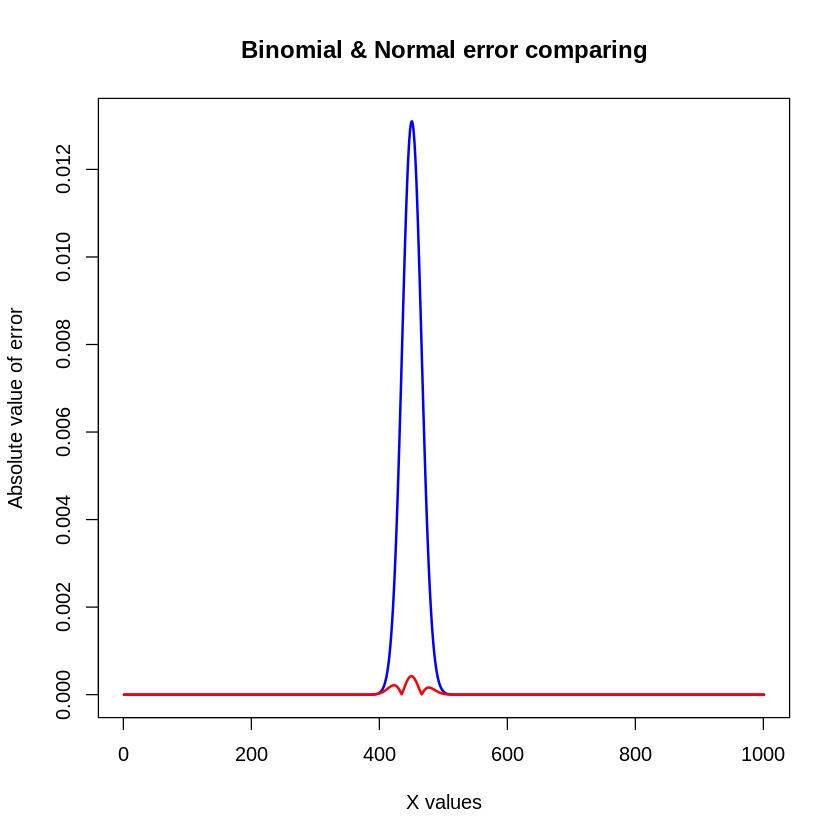

In [12]:
values <- 0:1000
mean <- n*p
std <- sqrt(n*p*(1-p))
without_correction <- numeric(length(values))
with_correction <- numeric(length(values))
 for(i in seq_along(values)){
  cdf <- Bin_cdf(n,p,0:values[i])
  normal_distribution <- pnorm(values[i],m=mean,s=std)
  without_correction[i] <- abs(cdf - normal_distribution)
  normal_distribution_with_correction <-pnorm(values[i]+0.5,m=mean,s=std)
  with_correction[i] <- abs(cdf - normal_distribution_with_correction)
 }

 plot(without_correction,type ="l",col="blue",lwd=2,xlab="X values", ylab="Absolute value of error",main="Binomial & Normal error comparing")
 lines(with_correction,col="red",lwd=2)




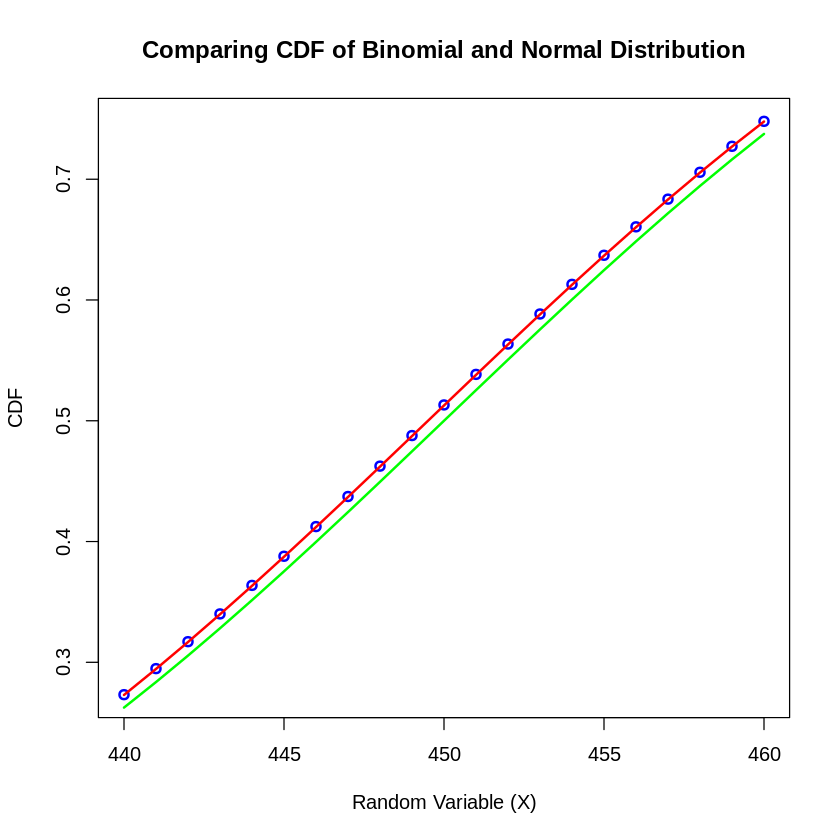

In [18]:
values <- seq(440, 460, by=1)
mean <-n*p
std <- sqrt(n*p*(1-p))
cdf<- c()
without_correction <- pnorm(values,m=mean,s=std)
with_correction <- pnorm(values+0.5,m=mean,s=std)
for(i in seq_along(values)){
  cdf <- c(cdf,Bin_cdf(n,p,0:values[i]))
}

plot(values, cdf, col = "blue", lwd = 2, xlab = "Random Variable (X)"
,ylab = "CDF", main = "Comparing CDF of Binomial and Normal Distribution", lty = 2)
lines(values, with_correction, col = "red", lwd = 2)
lines(values, without_correction, col = "green", lwd = 2)
